# EDA — Nakdong River disinfection by-product formation potential (THMFP / HAAFP)

Source: `data/20260909 DBP Viet.xlsx`, sheet `Total`. 44 sampling points × 16 monthly dates
(May 2017 – Aug 2018). 18 input variables (field, lab, UV/size, LC-OCD fractions) and two outputs
(THMFP, HAAFP). The EDA is **model-oriented**: which predictors can a THMFP/HAAFP model use, on how
many rows, and with what caveats.

Cleaning rules live in `preprocessing/load.py`; figure style in `preprocessing/style.py`. Every figure is
saved to `figures/`.

In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import NullFormatter
from scipy import stats

from preprocessing.load import (load_clean, VAR_GROUPS, PREDICTORS, TARGETS, NUMERIC, UNITS,
                                GROUP_ORDER, GROUP_LABEL, SITE_ORDER, STAGE_ORDER, PROCESSED_PATH)
from preprocessing import style
style.apply()
GC = style.GROUP_COLORS

pd.set_option("display.width", 160, "display.max_columns", 40, "display.precision", 3)
df = load_clean()
df.to_csv(PROCESSED_PATH, index=False)
river = df[df.group != "treatment"]      # main stem + tributary + reservoir
print(df.shape, "| river rows:", len(river), "| treatment rows:", (df.group == "treatment").sum())

(704, 36) | river rows: 464 | treatment rows: 240


## 1. Load & schema

In [2]:
schema = pd.DataFrame({
    "var_no": range(1, 21),
    "variable": NUMERIC,
    "block": [g for g, cols in VAR_GROUPS.items() for _ in cols],
    "unit (assumed)": [UNITS[c] for c in NUMERIC],
    "n_nonnull": [df[c].notna().sum() for c in NUMERIC],
    "n_unique": [df[c].nunique() for c in NUMERIC],
}).set_index("var_no")
schema

,variable,block,unit (assumed),n_nonnull,n_unique
var_no,,,,,
1,Temp,field,°C,693,234
2,pH,field,-,693,157
3,Turbidity,field,NTU,692,410
4,EC,field,µS/cm,693,459
5,DO,field,mg/L,549,220
6,SS,field,mg/L,468,147
7,Br,lab,mg/L,689,287
8,BOD,lab,mg/L,469,51
9,COD,lab,mg/L,469,86


In [3]:
sites = (df[["Site", "Name_EN", "group", "wtp", "stage"]].drop_duplicates("Site")
         .sort_values("Site").reset_index(drop=True))
sites.groupby("group", observed=True).size().rename("n_sites").to_frame().T

group,main_stem,tributary,reservoir,treatment
n_sites,18,6,5,15


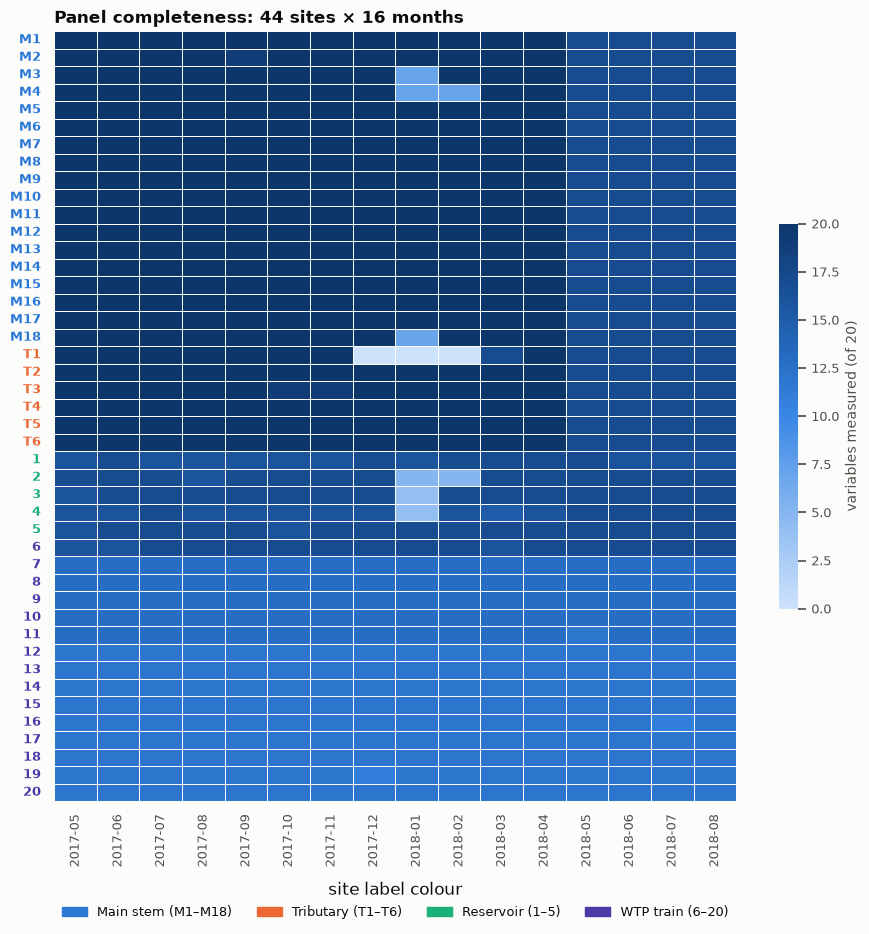

rows with <=2 measured variables:


,Date,Site,Name_EN,n_measured
326,2017-12-01,T1,Wicheon 6,0
370,2018-01-01,T1,Wicheon 6,0
414,2018-02-01,T1,Wicheon 6,0


In [4]:
# Panel completeness: number of measured variables per Site x Date (20 = all present)
panel = df.pivot_table(index="Site", columns="Date", values="n_measured", observed=True)
fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(panel, cmap=style.SEQ_CMAP, vmin=0, vmax=20, ax=ax, linewidths=0.5, linecolor=style.SURFACE,
            cbar_kws={"label": "variables measured (of 20)", "shrink": 0.5})
ax.set_xticklabels([d.strftime("%Y-%m") for d in panel.columns], rotation=90)
ax.set_title("Panel completeness: 44 sites × 16 months")
ax.set_xlabel(""); ax.set_ylabel("")
site_group = sites.set_index("Site")["group"]
for lab in ax.get_yticklabels():                      # colour site labels by group (legend below)
    lab.set_color(GC[site_group[lab.get_text()]]); lab.set_fontweight("bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=GC[g], label=GROUP_LABEL[g]) for g in GROUP_ORDER],
          loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=4, frameon=False, title="site label colour")
style.savefig(fig, "01_panel_completeness"); plt.show()
blank = df[df.n_measured <= 2][["Date", "Site", "Name_EN", "n_measured"]]
print("rows with <=2 measured variables:"); blank

## 2. Missingness

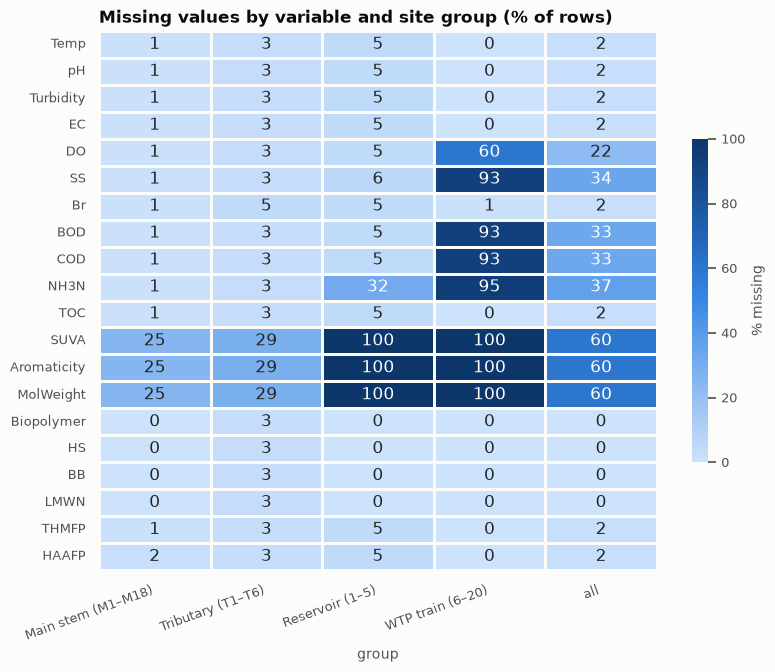

In [5]:
miss = (df[NUMERIC].isna().groupby(df.group, observed=True).mean() * 100).T[GROUP_ORDER]
miss["all"] = df[NUMERIC].isna().mean() * 100
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(miss.round(0), annot=True, fmt=".0f", cmap=style.SEQ_CMAP, vmin=0, vmax=100, ax=ax,
            linewidths=1, linecolor=style.SURFACE, cbar_kws={"label": "% missing", "shrink": 0.6})
ax.set_xticklabels([GROUP_LABEL.get(c, c) for c in miss.columns], rotation=20, ha="right")
ax.set_title("Missing values by variable and site group (% of rows)"); ax.set_ylabel("")
style.savefig(fig, "02_missingness"); plt.show()

In [6]:
nd = pd.Series({c[:-3]: int(df[c].sum()) for c in df.columns if c.endswith("_nd")}, name="non-detect (불검출) count")
print(nd.to_frame().T.to_string())
print("\nRows where SUVA/Aromaticity/MolWeight were literal 0 (set to NaN):")
df.loc[df.uv_zero_placeholder, ["Date", "Site", "Name_EN"]]

                        Turbidity  SS  Br  NH3N
non-detect (불검출) count          1   1   2    25

Rows where SUVA/Aromaticity/MolWeight were literal 0 (set to NaN):


,Date,Site,Name_EN
326,2017-12-01,T1,Wicheon 6
370,2018-01-01,T1,Wicheon 6
414,2018-02-01,T1,Wicheon 6
458,2018-03-01,T1,Wicheon 6


## 3. Targets: THMFP and HAAFP

Both are formation potentials (mg/L). Look at their shape, how they differ across site groups and sites,
how they move through the year, how they relate to each other, and what the treatment trains do to them.

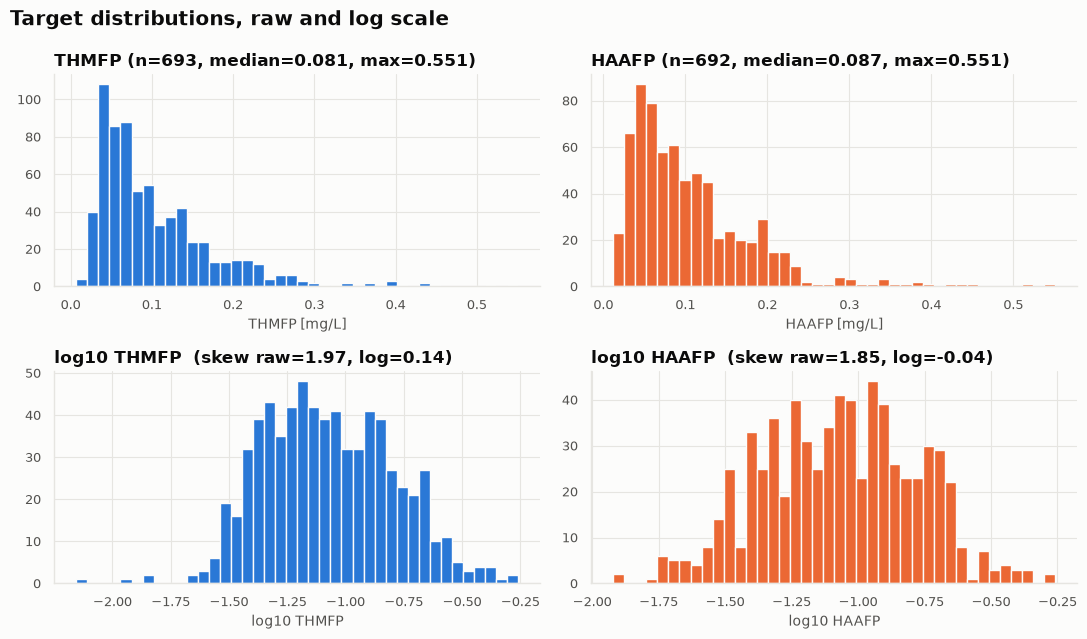

,count,mean,std,min,25%,50%,75%,max
THMFP,693.0,0.104,0.075,0.007,0.052,0.081,0.134,0.551
HAAFP,692.0,0.105,0.074,0.012,0.052,0.087,0.137,0.551


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for j, t in enumerate(TARGETS):
    s = df[t].dropna()
    axes[0, j].hist(s, bins=40, color=style.TARGET_COLORS[t], edgecolor=style.SURFACE)
    axes[0, j].set_title(f"{t} (n={len(s)}, median={s.median():.3f}, max={s.max():.3f})")
    axes[0, j].set_xlabel(f"{t} [{UNITS[t]}]")
    axes[1, j].hist(np.log10(s), bins=40, color=style.TARGET_COLORS[t], edgecolor=style.SURFACE)
    axes[1, j].set_title(f"log10 {t}  (skew raw={s.skew():.2f}, log={np.log10(s).skew():.2f})")
    axes[1, j].set_xlabel(f"log10 {t}")
fig.suptitle("Target distributions, raw and log scale", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); style.savefig(fig, "03_target_hist"); plt.show()
df[TARGETS].describe().T

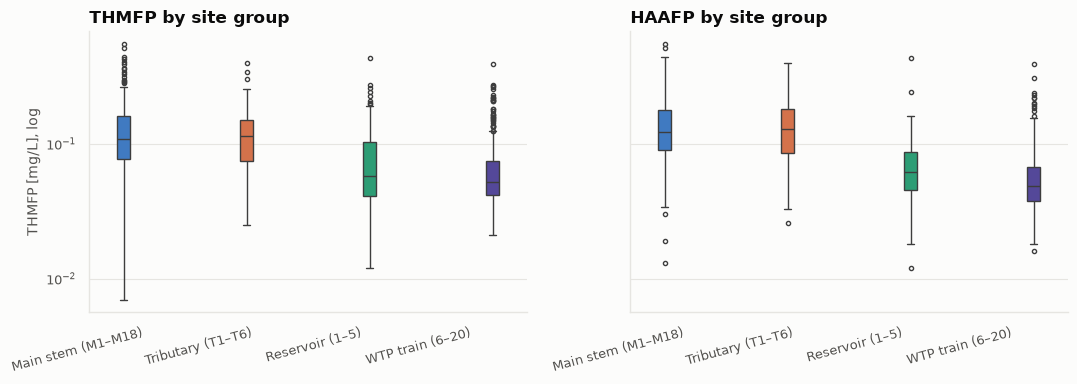

,THMFP,HAAFP
group,,
main_stem,0.108,0.122
tributary,0.114,0.130
reservoir,0.058,0.062
treatment,0.052,0.049


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, t in zip(axes, TARGETS):
    sns.boxplot(data=df, x="group", y=t, hue="group", palette=GC, legend=False, ax=ax, width=0.5,
                fliersize=3, linewidth=1)
    ax.set_xticks(range(4)); ax.set_xticklabels([GROUP_LABEL[g] for g in GROUP_ORDER], rotation=15, ha="right")
    ax.set_yscale("log"); ax.set_xlabel(""); ax.set_ylabel(f"{t} [{UNITS[t]}], log")
    ax.set_title(f"{t} by site group")
fig.tight_layout(); style.savefig(fig, "04_target_by_group"); plt.show()
df.groupby("group", observed=True)[TARGETS].median().round(3)

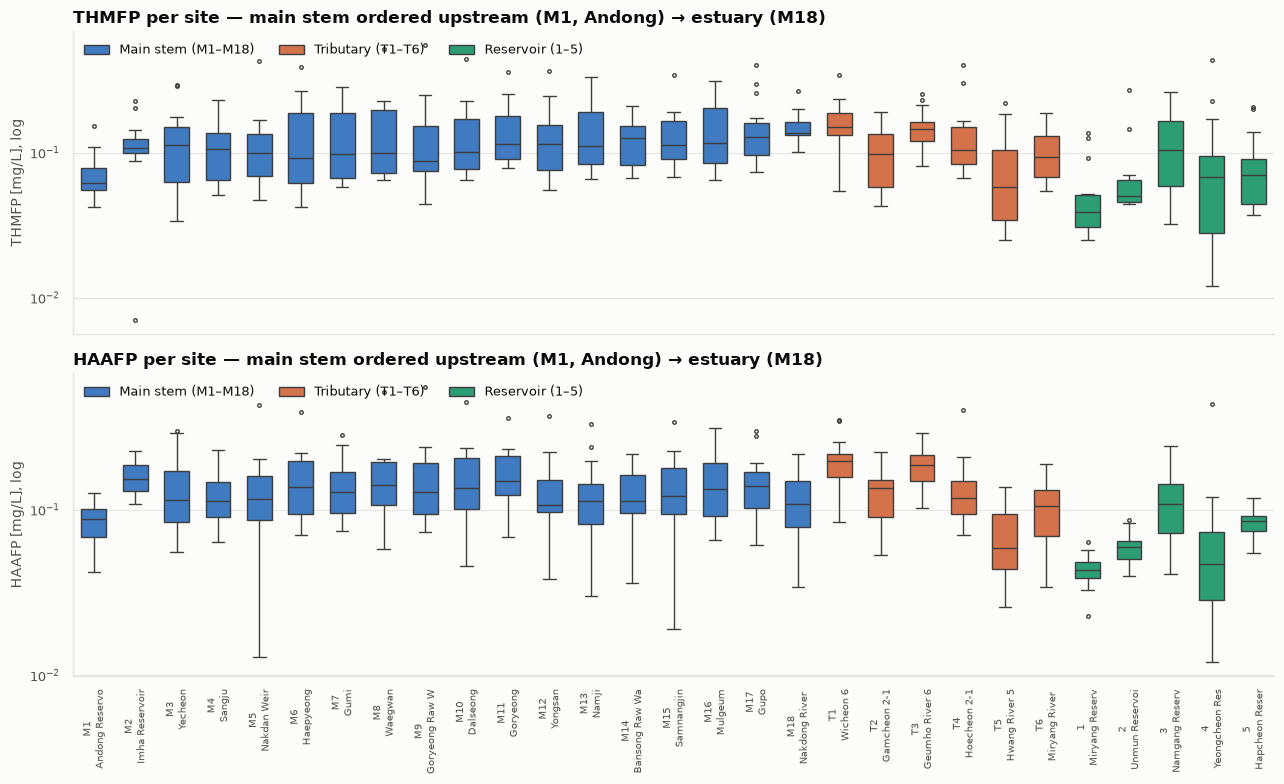

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
river_sites = [s for s in SITE_ORDER if df.loc[df.Site == s, "group"].iloc[0] != "treatment"]
for ax, t in zip(axes, TARGETS):
    sub = df[df.Site.isin(river_sites)].copy(); sub["Site"] = sub["Site"].cat.remove_unused_categories()
    sns.boxplot(data=sub, x="Site", y=t, hue="group", palette=GC, ax=ax, width=0.6, fliersize=2.5,
                linewidth=1, dodge=False)
    ax.set_yscale("log"); ax.set_ylabel(f"{t} [{UNITS[t]}], log"); ax.set_xlabel("")
    ax.set_title(f"{t} per site — main stem ordered upstream (M1, Andong) → estuary (M18)")
    ax.legend(handles=ax.get_legend_handles_labels()[0][:3], labels=[GROUP_LABEL[g] for g in GROUP_ORDER[:3]],
              loc="upper left", ncol=3)
axes[1].set_xticks(range(len(river_sites)))
axes[1].set_xticklabels([f"{s}\n{df.loc[df.Site == s, 'Name_EN'].iloc[0][:14]}" for s in river_sites],
                        rotation=90, fontsize=7.5)
fig.tight_layout(); style.savefig(fig, "05_target_by_site"); plt.show()

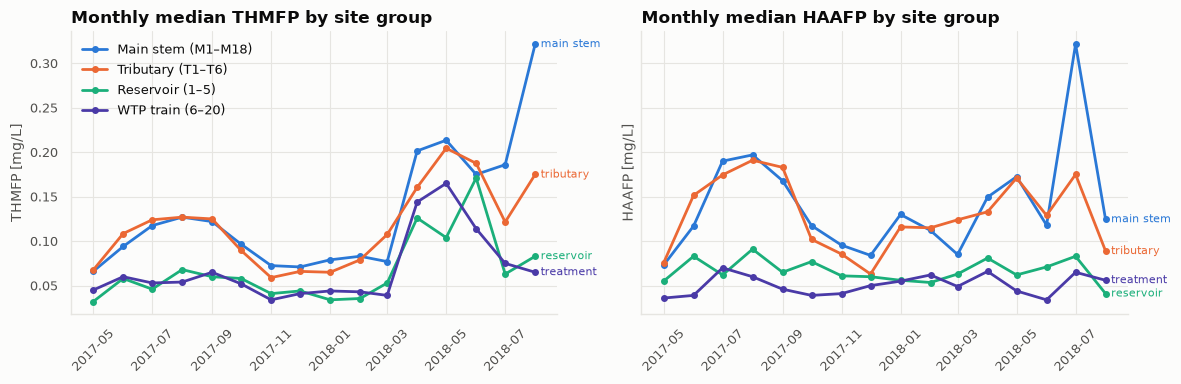

In [10]:
monthly = df.groupby(["Date", "group"], observed=True)[TARGETS].median().reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, t in zip(axes, TARGETS):
    for g in GROUP_ORDER:
        m = monthly[monthly.group == g]
        ax.plot(m.Date, m[t], color=GC[g], label=GROUP_LABEL[g], marker="o", markersize=4)
        ax.annotate(g.replace("_", " "), (m.Date.iloc[-1], m[t].iloc[-1]), xytext=(4, 0),
                    textcoords="offset points", fontsize=8, color=GC[g], va="center")
    ax.set_title(f"Monthly median {t} by site group"); ax.set_ylabel(f"{t} [{UNITS[t]}]")
    ax.tick_params(axis="x", rotation=45)
axes[0].legend(loc="upper left")
fig.tight_layout(); style.savefig(fig, "06_target_monthly"); plt.show()

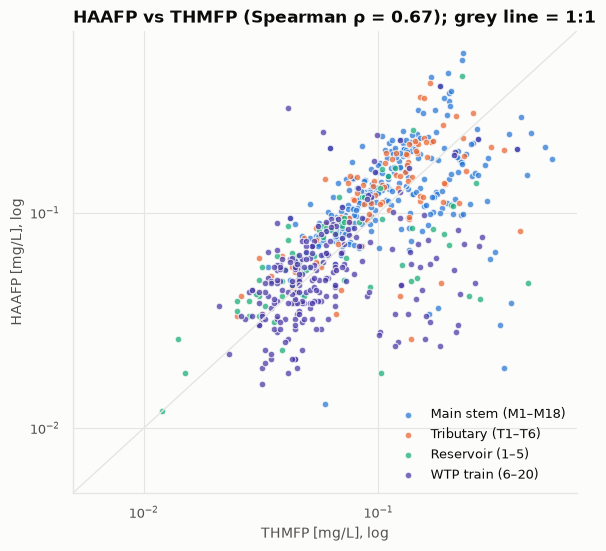

Spearman THMFP~HAAFP by group:


group
main_stem    0.59
tributary    0.69
reservoir    0.59
treatment    0.45
dtype: float64

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for g in GROUP_ORDER:
    s = df[df.group == g]
    ax.scatter(s.THMFP, s.HAAFP, s=22, color=GC[g], alpha=0.75, label=GROUP_LABEL[g],
               edgecolors=style.SURFACE, linewidths=0.8)
lim = [0.005, 0.7]; ax.plot(lim, lim, color=style.GRID, lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xscale("log"); ax.set_yscale("log")
rho = stats.spearmanr(df.THMFP, df.HAAFP, nan_policy="omit")[0]
ax.set_title(f"HAAFP vs THMFP (Spearman ρ = {rho:.2f}); grey line = 1:1")
ax.set_xlabel("THMFP [mg/L], log"); ax.set_ylabel("HAAFP [mg/L], log"); ax.legend(loc="lower right")
style.savefig(fig, "07_thmfp_vs_haafp"); plt.show()
print("Spearman THMFP~HAAFP by group:")
df.groupby("group", observed=True).apply(lambda s: stats.spearmanr(s.THMFP, s.HAAFP, nan_policy="omit")[0]).round(2)

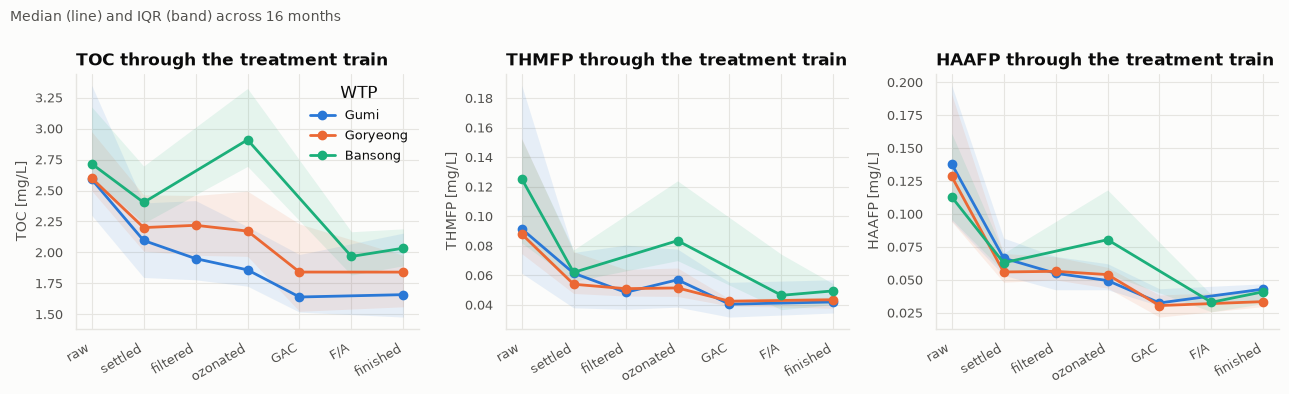

wtp      Bansong               Goryeong                 Gumi              
           HAAFP  THMFP    TOC    HAAFP  THMFP    TOC  HAAFP  THMFP    TOC
stage                                                                     
raw        0.113  0.126  2.716    0.128  0.088  2.600  0.138  0.092  2.590
settled    0.063  0.062  2.404    0.056  0.054  2.200  0.066  0.062  2.096
filtered     NaN    NaN    NaN    0.056  0.051  2.219  0.055  0.048  1.950
ozonated   0.080  0.084  2.910    0.054  0.052  2.172  0.050  0.057  1.859
GAC          NaN    NaN    NaN    0.030  0.042  1.842  0.032  0.040  1.640
F/A        0.033  0.046  1.968      NaN    NaN    NaN    NaN    NaN    NaN
finished   0.041  0.050  2.034    0.034  0.044  1.841  0.043  0.042  1.659

In [12]:
# Treatment train: raw -> finished per WTP (median over 16 months, with IQR band)
train = df[df.wtp.notna()].copy()
train["stage"] = train["stage"].cat.remove_unused_categories()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, var in zip(axes, ["TOC", "THMFP", "HAAFP"]):
    for w, c in style.WTP_COLORS.items():
        g = train[train.wtp == w].groupby("stage", observed=True)[var]
        med, q1, q3 = g.median(), g.quantile(0.25), g.quantile(0.75)
        x = [STAGE_ORDER.index(s) for s in med.index]
        ax.plot(x, med.values, color=c, marker="o", label=w)
        ax.fill_between(x, q1.values, q3.values, color=c, alpha=0.10, linewidth=0)
    ax.set_xticks(range(len(STAGE_ORDER))); ax.set_xticklabels(STAGE_ORDER, rotation=30, ha="right")
    ax.set_title(f"{var} through the treatment train"); ax.set_ylabel(f"{var} [{UNITS[var]}]")
axes[0].legend(title="WTP")
fig.suptitle("Median (line) and IQR (band) across 16 months", x=0.01, ha="left", fontsize=10, color=style.TEXT_2)
fig.tight_layout(); style.savefig(fig, "08_treatment_train"); plt.show()
(train.groupby(["wtp", "stage"], observed=True)[["TOC", "THMFP", "HAAFP"]].median().round(3)
      .unstack("wtp").swaplevel(axis=1).sort_index(axis=1))

## 4. Predictor distributions and outliers

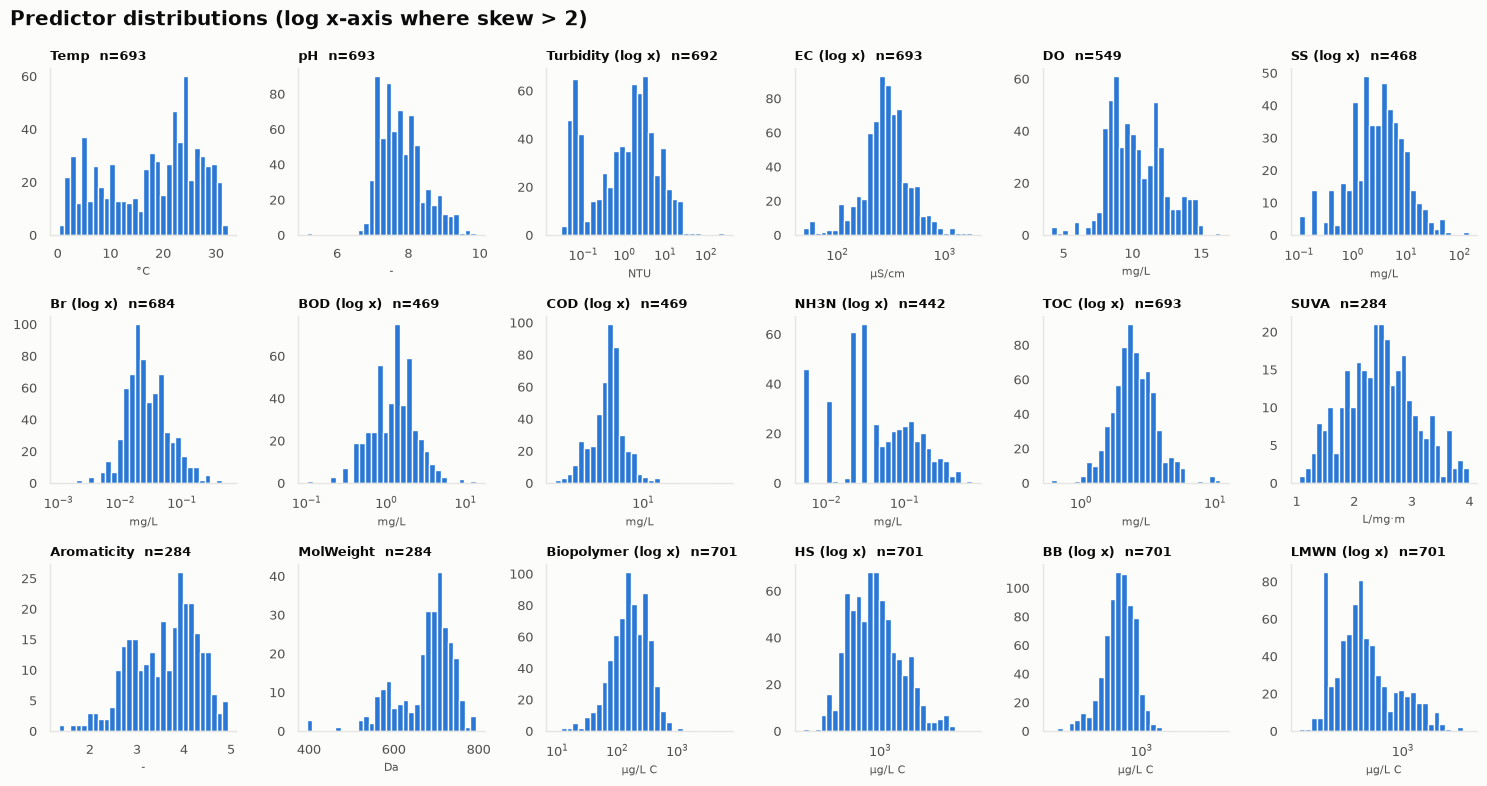

log-scale candidates (skew > 2): ['Turbidity', 'EC', 'SS', 'Br', 'BOD', 'COD', 'NH3N', 'TOC', 'Biopolymer', 'HS', 'BB', 'LMWN']


In [13]:
skewed = [c for c in PREDICTORS if df[c].dropna().skew() > 2]
fig, axes = plt.subplots(3, 6, figsize=(15, 8)); axes = axes.ravel()
for ax, c in zip(axes, PREDICTORS):
    s = df[c].dropna()
    if c in skewed:
        s = s[s > 0]; bins = np.logspace(np.log10(s.min()), np.log10(s.max()), 30); ax.set_xscale("log")
        ax.xaxis.set_minor_formatter(NullFormatter())
    else:
        bins = 30
    ax.hist(s, bins=bins, color=GC["main_stem"], edgecolor=style.SURFACE)
    ax.set_title(f"{c}{' (log x)' if c in skewed else ''}  n={len(s)}", fontsize=9.5)
    ax.set_xlabel(UNITS[c], fontsize=8); ax.grid(False)
fig.suptitle("Predictor distributions (log x-axis where skew > 2)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); style.savefig(fig, "09_predictor_hist"); plt.show()
print("log-scale candidates (skew > 2):", skewed)

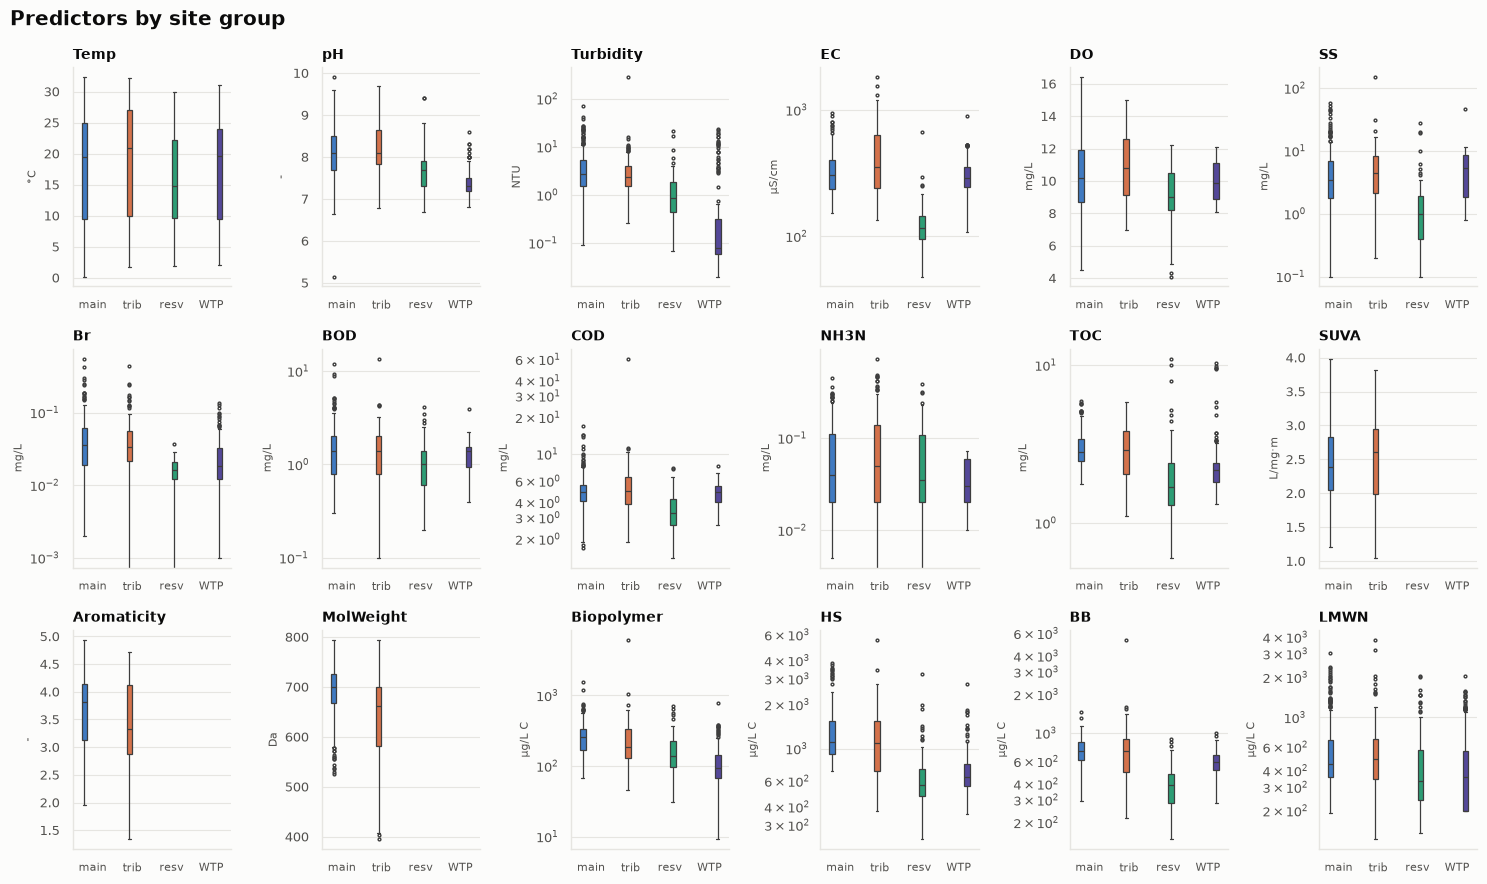

In [14]:
fig, axes = plt.subplots(3, 6, figsize=(15, 9)); axes = axes.ravel()
for ax, c in zip(axes, PREDICTORS):
    sns.boxplot(data=df, x="group", y=c, hue="group", palette=GC, legend=False, ax=ax, width=0.55,
                fliersize=2, linewidth=0.9)
    if c in skewed: ax.set_yscale("log")
    ax.set_title(c, fontsize=10); ax.set_xlabel(""); ax.set_ylabel(UNITS[c], fontsize=8)
    ax.set_xticks(range(4)); ax.set_xticklabels(["main", "trib", "resv", "WTP"], fontsize=8)
fig.suptitle("Predictors by site group", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); style.savefig(fig, "10_predictor_by_group"); plt.show()

In [15]:
# Robust outliers: |modified z| > 3.5 using MAD, computed on log10 for skewed vars, within river vs treatment
def robust_z(s):
    med = s.median(); mad = (s - med).abs().median()
    return 0.6745 * (s - med) / mad if mad > 0 else pd.Series(0.0, index=s.index)

rows = []
for c in NUMERIC:
    for grp, sub in df.groupby(df.group == "treatment"):
        s = sub[c].dropna()
        z = robust_z(np.log10(s[s > 0]) if c in skewed else s)
        for idx in z[z.abs() > 3.5].index:
            rows.append({"variable": c, "Date": df.at[idx, "Date"].date(), "Site": df.at[idx, "Site"],
                         "Name_EN": df.at[idx, "Name_EN"], "value": df.at[idx, c], "robust_z": round(z[idx], 1)})
outliers = pd.DataFrame(rows).sort_values(["variable", "robust_z"], key=lambda s: s if s.name != "robust_z" else -s.abs())
print(outliers.groupby("variable").size().sort_values(ascending=False).to_string())
outliers.head(40)

variable
THMFP         49
Turbidity     33
HAAFP         27
TOC           12
COD           10
HS            10
EC             9
BB             7
MolWeight      7
Biopolymer     4
Br             3
LMWN           3
BOD            2
pH             2


,variable,Date,Site,Name_EN,value,robust_z
97,BB,2018-08-01,T4,Hoecheon 2-1,5329.056,5.9
92,BB,2017-11-01,4,Yeongcheon Reservoir (Jukjangcheon),147.931,-4.4
93,BB,2017-12-01,4,Yeongcheon Reservoir (Jukjangcheon),147.931,-4.4
94,BB,2018-01-01,4,Yeongcheon Reservoir (Jukjangcheon),147.931,-4.4
95,BB,2018-02-01,4,Yeongcheon Reservoir (Jukjangcheon),176.801,-3.8
96,BB,2018-06-01,1,Miryang Reservoir,178.847,-3.8
98,BB,2018-01-01,19,Bansong F/A-Treated Water,282.752,-3.6
47,BOD,2018-03-01,T5,Hwang River 5,0.100,-4.0
48,BOD,2018-08-01,T4,Hoecheon 2-1,13.600,3.7
78,Biopolymer,2018-08-01,T4,Hoecheon 2-1,6102.325,5.7


## 5. Predictor–target relationships

Spearman (rank) correlation is used as the default because most variables are right-skewed and the
relationships need not be linear. River rows and treatment-train rows are shown separately where they
behave differently.

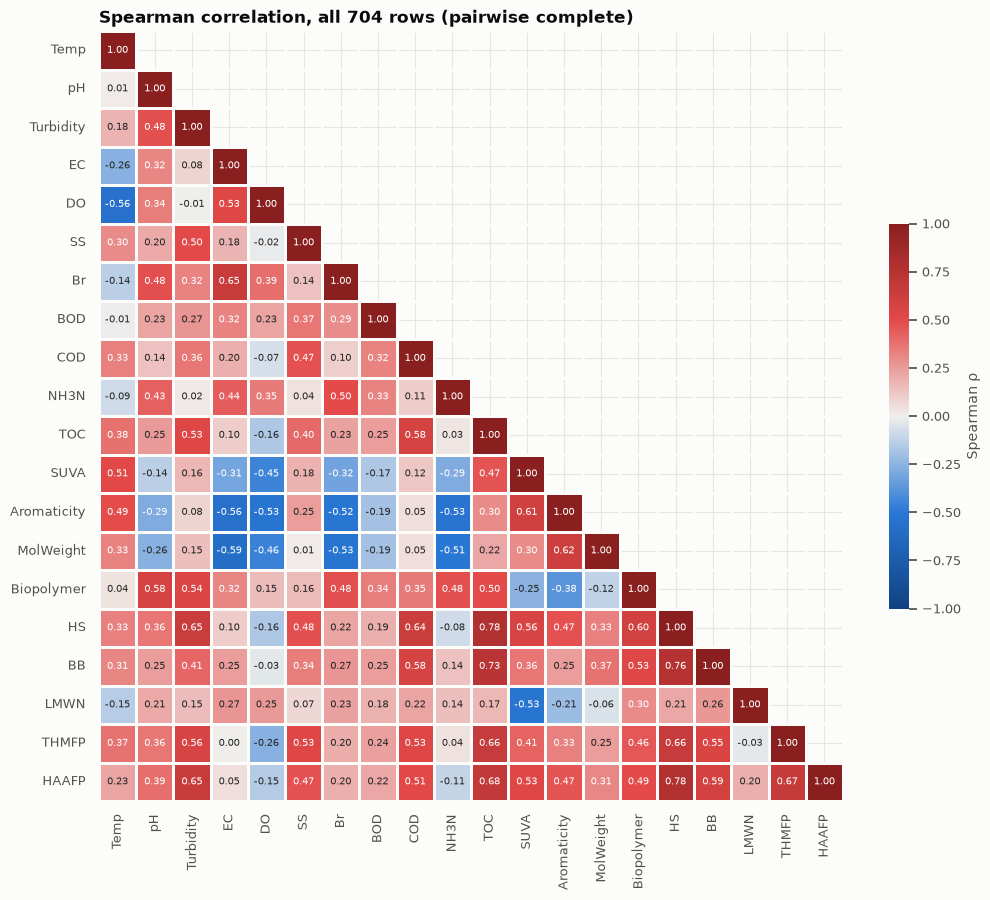

In [16]:
def spearman_matrix(d, cols):
    return d[cols].corr(method="spearman")

corr_all = spearman_matrix(df, NUMERIC)
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_all, dtype=bool), k=1)
sns.heatmap(corr_all, mask=mask, cmap=style.DIV_CMAP, vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, linewidths=1, linecolor=style.SURFACE, ax=ax, cbar_kws={"shrink": 0.5, "label": "Spearman ρ"})
ax.set_title("Spearman correlation, all 704 rows (pairwise complete)")
style.savefig(fig, "11_corr_spearman"); plt.show()

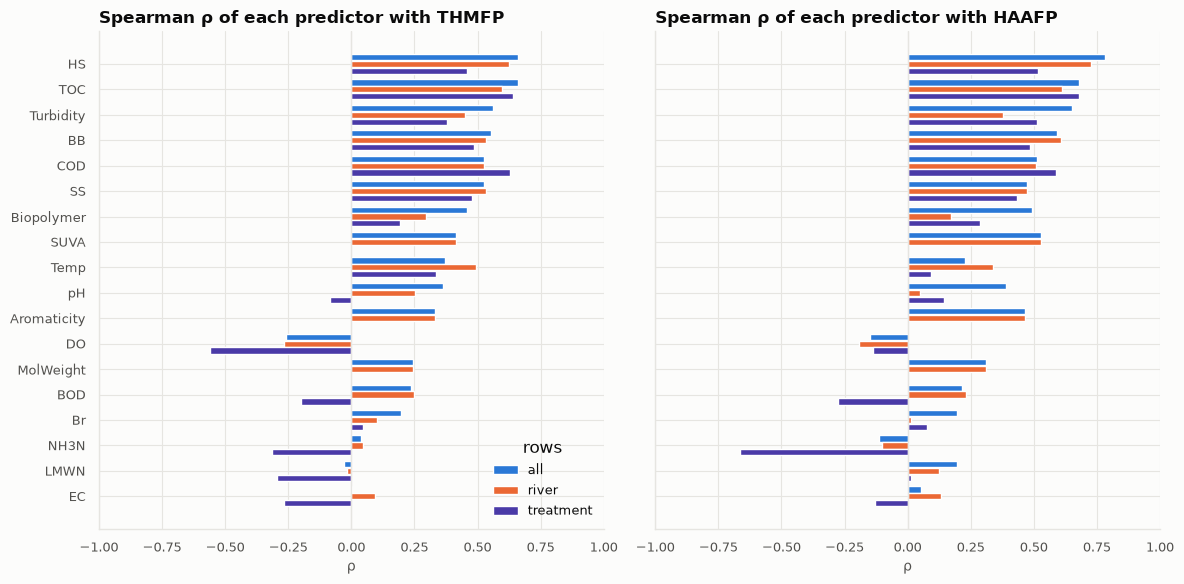

all                 river                 treatment                
            THMFP      HAAFP      THMFP      HAAFP          THMFP      HAAFP     
              rho    n   rho    n   rho    n   rho    n       rho    n   rho    n
HS           0.66  693  0.78  692  0.62  453  0.73  452      0.46  240  0.52  240
TOC          0.66  691  0.68  690  0.60  451  0.61  450      0.64  240  0.68  240
Turbidity    0.56  692  0.65  691  0.45  453  0.38  452      0.38  239  0.51  239
BB           0.55  693  0.59  692  0.53  453  0.61  452      0.49  240  0.48  240
SS           0.53  468  0.47  467  0.53  452  0.47  451      0.48   16  0.44   16
COD          0.53  469  0.51  468  0.52  453  0.51  452      0.63   16  0.59   16
Biopolymer   0.46  693  0.49  692  0.30  453  0.17  452      0.19  240  0.29  240
SUVA         0.41  280  0.53  279  0.41  280  0.53  279       NaN    0   NaN    0
Temp         0.37  693  0.23  692  0.50  453  0.34  452      0.34  240  0.09  240
pH           0.36  693  0.39  692  0.25  453  0.05  452     -0.08  240  0.14  240
Aromaticity  0.33  280  0.47  279  0.33  280  0.47  279       NaN    0   NaN    0
DO          -0.26  549 -0.15  548 -0.27  453 -0.19  452     -0.56   96 -0.14   96
MolWeight    0.25  280  0.31  279  0.25  280  0.31  279       NaN    0   NaN    0
BOD          0.24  469  0.22  468  0.25  453  0.23  452     -0.20   16 -0.27   16
Br           0.20  689  0.20  688  0.10  451  0.01  450      0.05  238  0.08  238
NH3N         0.04  444 -0.11  443  0.05  431 -0.10  430     -0.31   13 -0.67   13
LMWN        -0.03  693  0.20  692 -0.02  453  0.12  452     -0.30  240  0.02  240
EC           0.00  693  0.05  692  0.09  453  0.13  452     -0.27  240 -0.13  240

In [17]:
def target_corr(d, label):
    out = {}
    for t in TARGETS:
        r = {c: stats.spearmanr(d[c], d[t], nan_policy="omit") for c in PREDICTORS}
        out[(label, t, "rho")] = pd.Series({c: v[0] for c, v in r.items()})
        out[(label, t, "n")] = pd.Series({c: d[[c, t]].dropna().shape[0] for c in PREDICTORS})
    return pd.DataFrame(out)

tc = pd.concat([target_corr(df, "all"), target_corr(river, "river"), target_corr(df[df.group == "treatment"], "treatment")], axis=1)
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
order = tc[("all", "THMFP", "rho")].abs().sort_values(ascending=True).index
for ax, t in zip(axes, TARGETS):
    y = np.arange(len(order)); h = 0.27
    for k, (lab, off) in enumerate([("all", h), ("river", 0), ("treatment", -h)]):
        v = tc[(lab, t, "rho")].reindex(order)
        ax.barh(y + off, v, height=h * 0.9, color=[GC["main_stem"], GC["tributary"], GC["treatment"]][k], label=lab)
    ax.axvline(0, color=style.GRID, lw=1); ax.set_yticks(y); ax.set_yticklabels(order)
    ax.set_xlim(-1, 1); ax.set_title(f"Spearman ρ of each predictor with {t}"); ax.set_xlabel("ρ")
axes[0].legend(title="rows", loc="lower right")
fig.tight_layout(); style.savefig(fig, "12_corr_ranked"); plt.show()
tc.round(2).sort_values(("all", "THMFP", "rho"), key=abs, ascending=False)

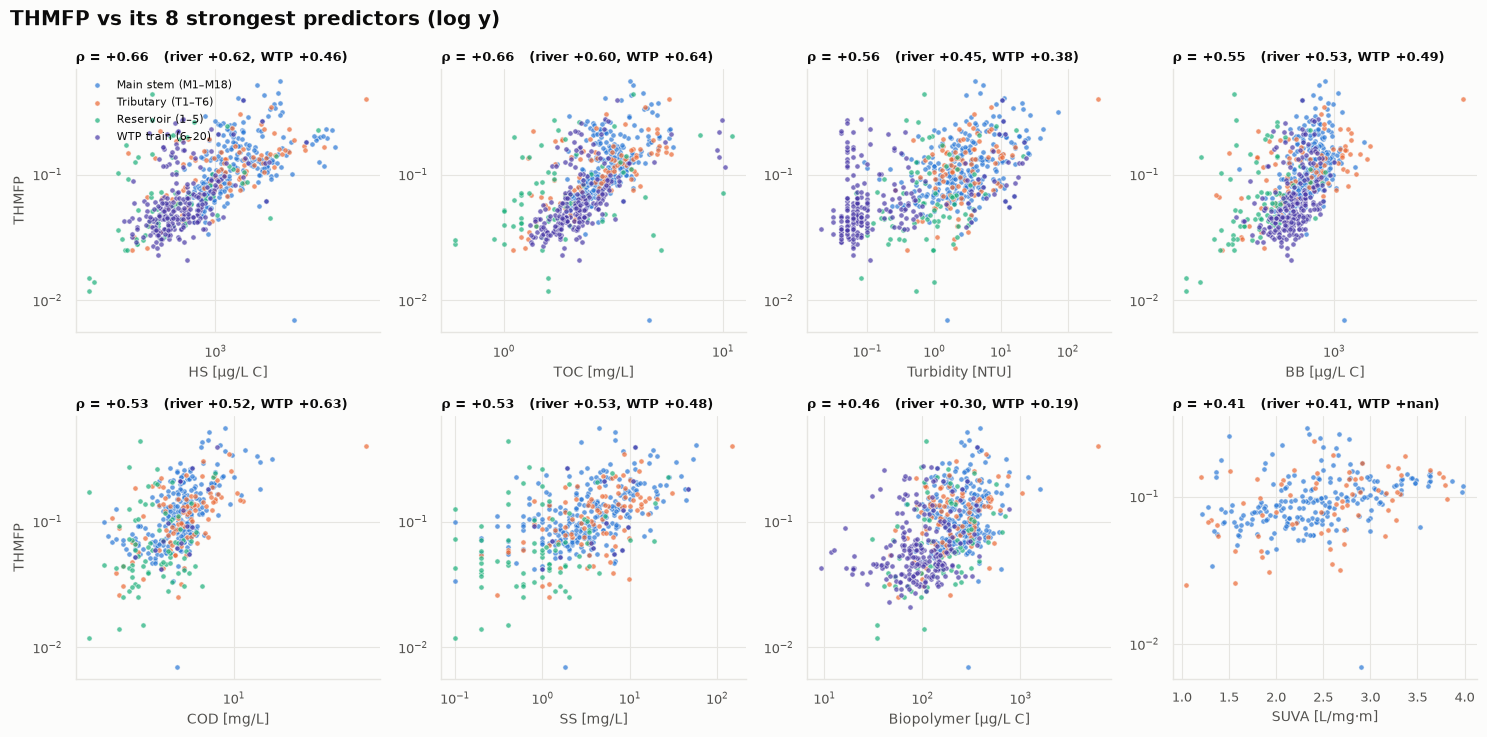

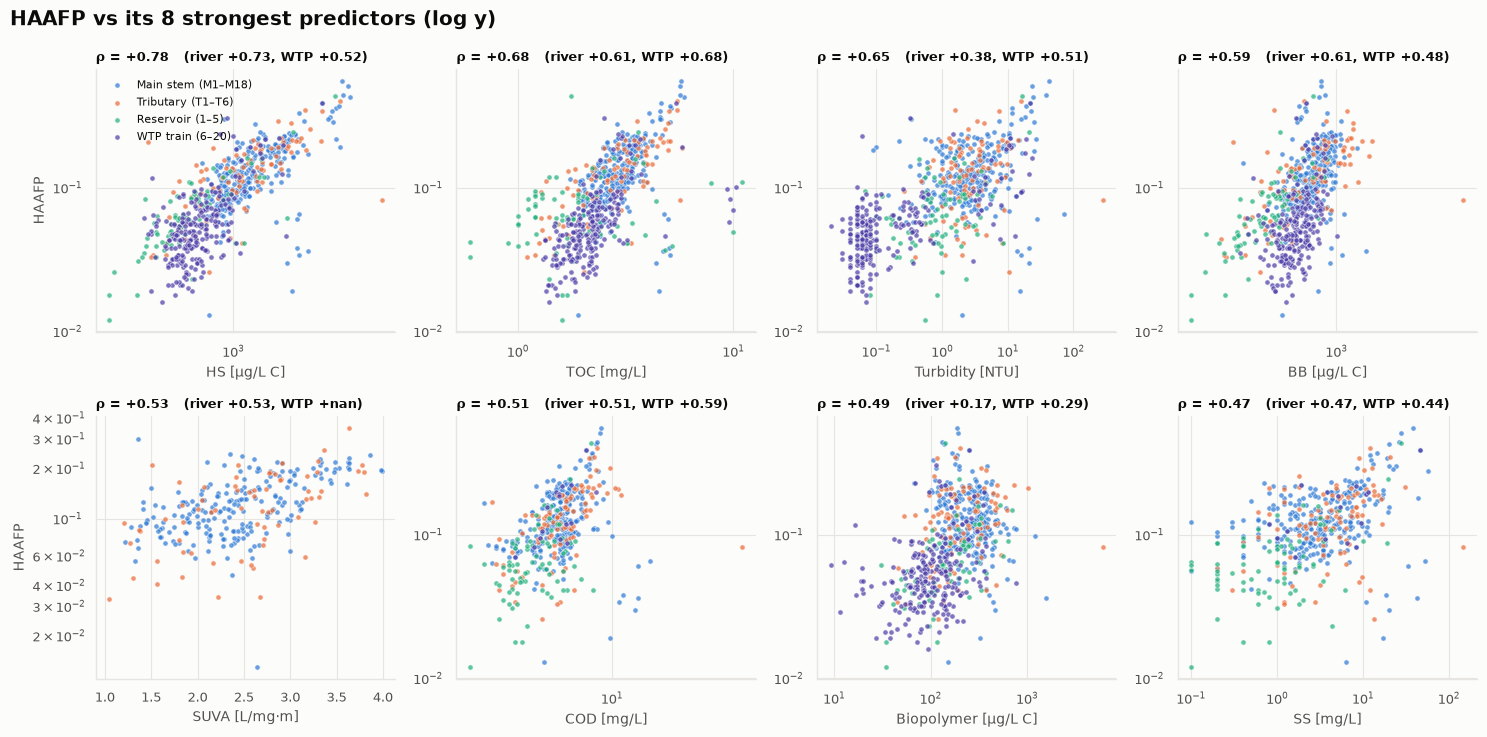

In [18]:
def scatter_grid(t, name):
    top = tc[("all", t, "rho")].abs().sort_values(ascending=False).index[:8]
    fig, axes = plt.subplots(2, 4, figsize=(15, 7.5)); axes = axes.ravel()
    for ax, c in zip(axes, top):
        for g in GROUP_ORDER:
            s = df[df.group == g]
            ax.scatter(s[c], s[t], s=14, color=GC[g], alpha=0.7, edgecolors=style.SURFACE, linewidths=0.5, label=GROUP_LABEL[g])
        if c in skewed: ax.set_xscale("log"); ax.xaxis.set_minor_formatter(NullFormatter())
        ax.set_yscale("log"); ax.set_xlabel(f"{c} [{UNITS[c]}]"); ax.set_ylabel(t if ax in axes[[0, 4]] else "")
        ax.set_title(f"ρ = {tc[('all', t, 'rho')][c]:+.2f}   (river {tc[('river', t, 'rho')][c]:+.2f}, WTP {tc[('treatment', t, 'rho')][c]:+.2f})", fontsize=9.5)
    axes[0].legend(loc="upper left", fontsize=8)
    fig.suptitle(f"{t} vs its 8 strongest predictors (log y)", x=0.01, ha="left", fontweight="bold")
    fig.tight_layout(); style.savefig(fig, name); plt.show()

scatter_grid("THMFP", "13_scatter_thmfp")
scatter_grid("HAAFP", "14_scatter_haafp")

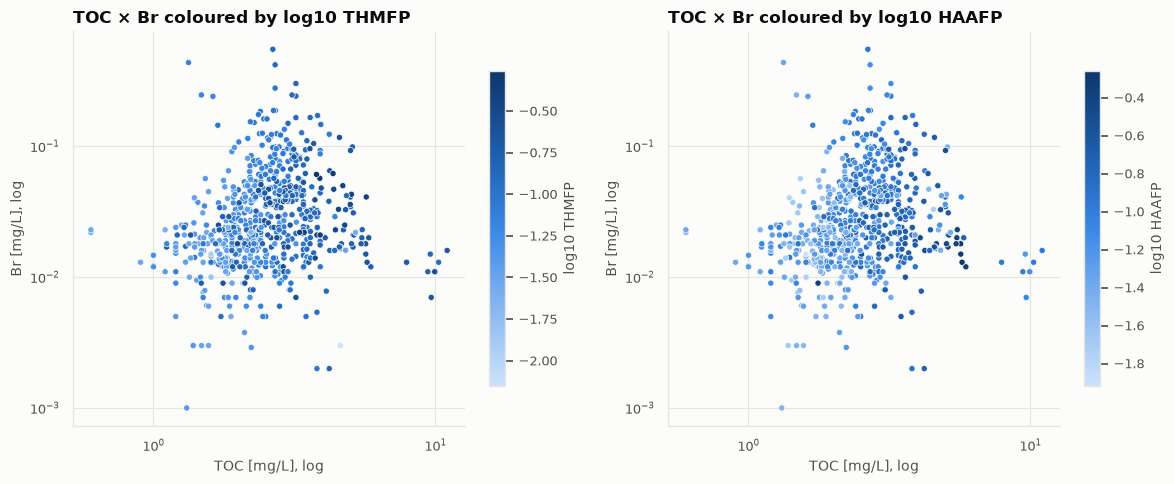

THMFP: log-log slope on TOC = 1.02; Spearman(resid, log Br) = +0.15  (n=682)
HAAFP: log-log slope on TOC = 1.06; Spearman(resid, log Br) = +0.09  (n=681)


In [19]:
# TOC x Br: classic DBP drivers. Colour = target (sequential), size fixed.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, t in zip(axes, TARGETS):
    s = df.dropna(subset=["TOC", "Br", t]); s = s[s.Br > 0]
    sc = ax.scatter(s.TOC, s.Br, c=np.log10(s[t]), cmap=style.SEQ_CMAP, s=20, edgecolors=style.SURFACE, linewidths=0.5)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("TOC [mg/L], log"); ax.set_ylabel("Br [mg/L], log"); ax.set_title(f"TOC × Br coloured by log10 {t}")
    cb = fig.colorbar(sc, ax=ax, shrink=0.8); cb.set_label(f"log10 {t}")
fig.tight_layout(); style.savefig(fig, "15_toc_br"); plt.show()
# partial: does Br add to TOC? Spearman of residuals from log-log fit on TOC
for t in TARGETS:
    s = df.dropna(subset=["TOC", "Br", t]); s = s[(s.Br > 0) & (s[t] > 0)]
    slope, icpt = np.polyfit(np.log10(s.TOC), np.log10(s[t]), 1)
    resid = np.log10(s[t]) - (slope * np.log10(s.TOC) + icpt)
    print(f"{t}: log-log slope on TOC = {slope:.2f}; Spearman(resid, log Br) = {stats.spearmanr(resid, np.log10(s.Br))[0]:+.2f}  (n={len(s)})")

## 6. Multicollinearity among predictors

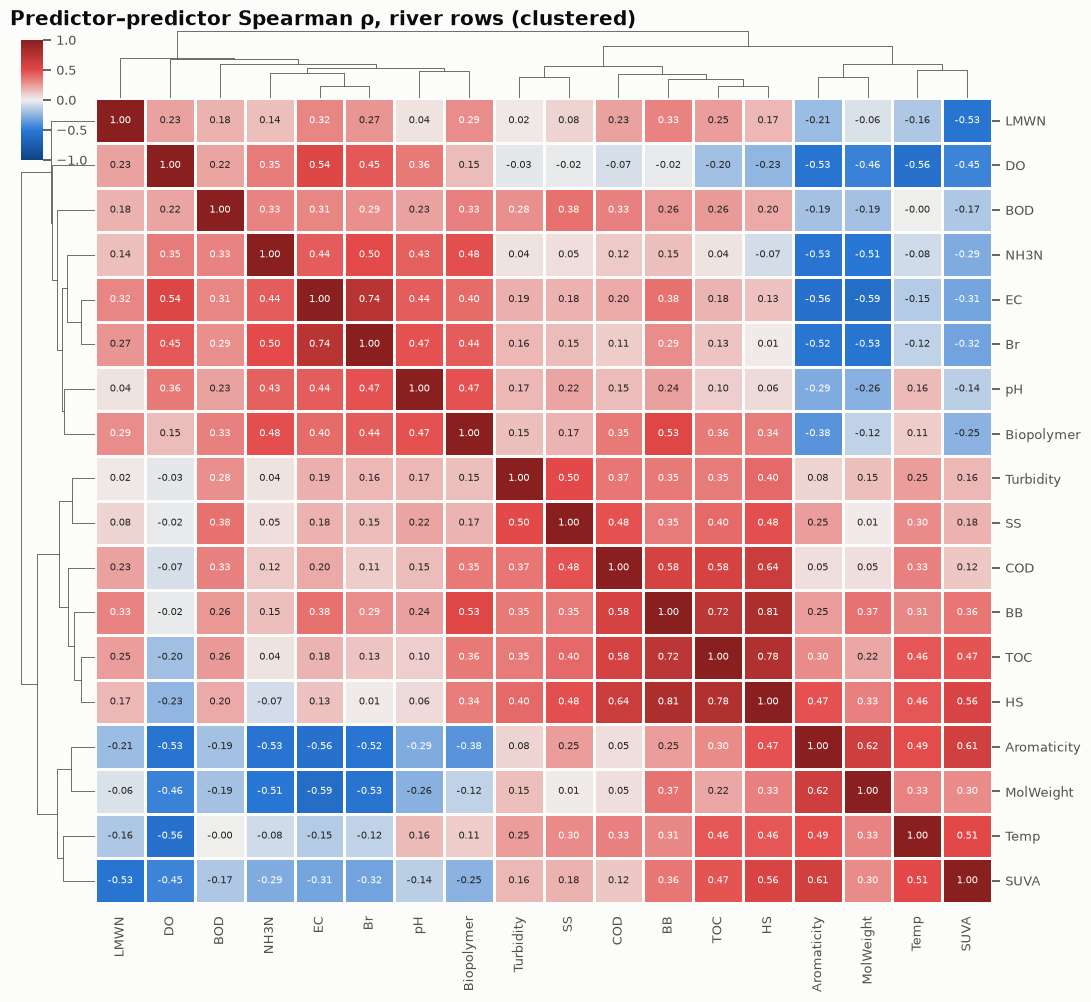

|ρ| > 0.7 predictor pairs (river rows):


,a,b,rho
286,HS,BB,0.810
195,TOC,HS,0.783
60,EC,Br,0.740
196,TOC,BB,0.719


In [20]:
pc = river[PREDICTORS].corr(method="spearman")
g = sns.clustermap(pc, cmap=style.DIV_CMAP, vmin=-1, vmax=1, center=0, annot=True, fmt=".2f", annot_kws={"size": 7},
                   figsize=(11, 10), linewidths=1, linecolor=style.SURFACE, dendrogram_ratio=0.08, cbar_pos=(0.02, 0.85, 0.02, 0.12))
g.fig.suptitle("Predictor–predictor Spearman ρ, river rows (clustered)", x=0.01, ha="left", fontweight="bold", y=1.0)
g.savefig(style.FIG_DIR / "16_predictor_corr.png"); plt.show()
pairs = (pc.where(np.triu(np.ones(pc.shape, bool), 1)).stack().rename("rho").reset_index()
           .rename(columns={"level_0": "a", "level_1": "b"}))
print("|ρ| > 0.7 predictor pairs (river rows):")
pairs[pairs.rho.abs() > 0.7].sort_values("rho", key=abs, ascending=False)

In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def vif_table(cols, d):
    X = d[cols].dropna(); X = X[(X > 0).all(axis=1)]
    Xl = X.copy()
    for c in cols:
        if c in skewed: Xl[c] = np.log10(X[c])
    Xl = (Xl - Xl.mean()) / Xl.std()
    Xc = np.column_stack([np.ones(len(Xl)), Xl.values])
    return pd.Series({c: variance_inflation_factor(Xc, i + 1) for i, c in enumerate(cols)}, name=f"VIF (n={len(Xl)})")

set_b = [c for c in PREDICTORS if c not in VAR_GROUPS["uv_size"]]
set_c = [c for c in set_b if c not in ["DO", "SS", "BOD", "COD", "NH3N"]]
pd.concat([vif_table(PREDICTORS, river).rename("A: all 18 (river)"),
           vif_table(set_b, river).rename("B: no UV/size (river)"),
           vif_table(set_c, df).rename("C: core 10 (all rows)")], axis=1).round(1)

,A: all 18 (river),B: no UV/size (river),C: core 10 (all rows)
Temp,3.5,2.8,1.5
pH,1.9,1.9,1.7
Turbidity,1.2,1.6,2.4
EC,3.8,2.8,2.1
DO,3.5,2.8,NaN
SS,1.4,1.8,NaN
Br,3.2,2.5,2.1
BOD,1.7,1.5,NaN
COD,1.7,2.5,NaN
NH3N,2.4,1.8,NaN


## 7. Seasonality and spatial structure

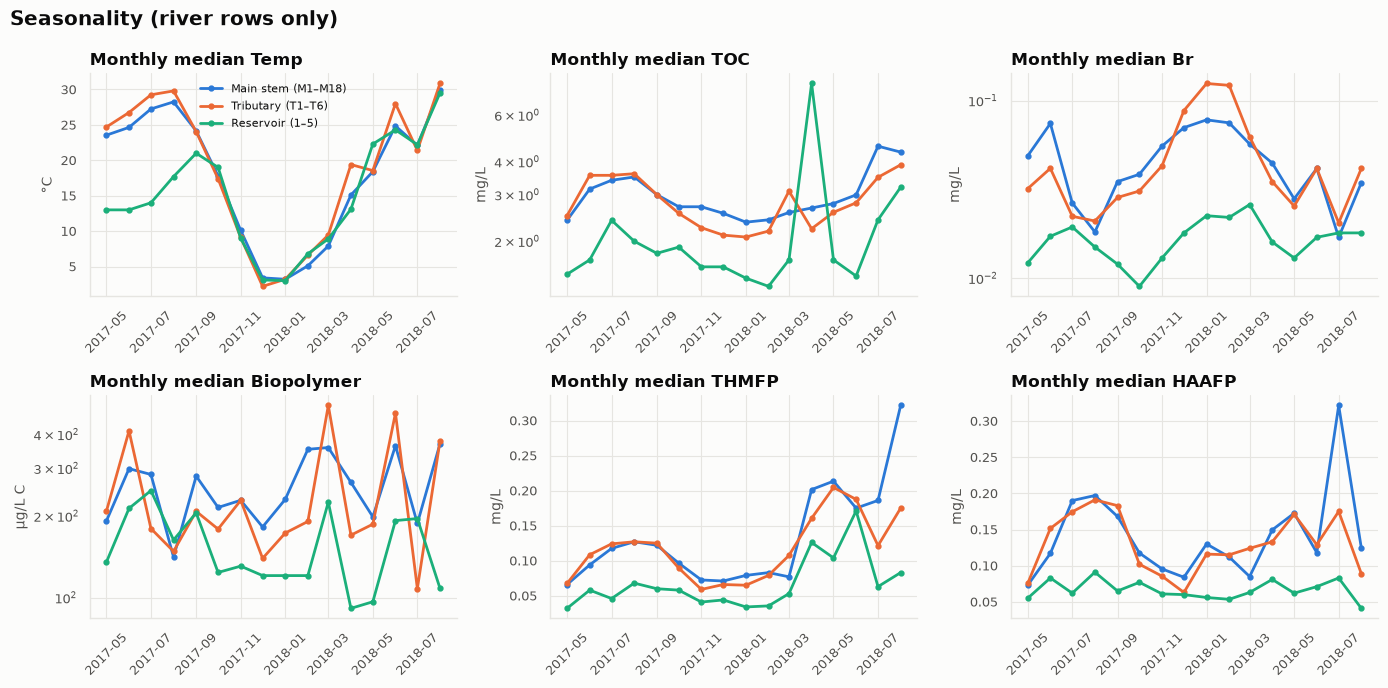

In [22]:
vars_ = ["Temp", "TOC", "Br", "Biopolymer", "THMFP", "HAAFP"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7)); axes = axes.ravel()
for ax, v in zip(axes, vars_):
    for g in GROUP_ORDER[:3]:
        m = river[river.group == g].groupby("Date", observed=True)[v].median()
        ax.plot(m.index, m.values, color=GC[g], marker="o", markersize=3.5, label=GROUP_LABEL[g])
    ax.set_title(f"Monthly median {v}"); ax.set_ylabel(UNITS[v]); ax.tick_params(axis="x", rotation=45)
    if v in skewed: ax.set_yscale("log")
axes[0].legend(fontsize=8)
fig.suptitle("Seasonality (river rows only)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); style.savefig(fig, "17_seasonal"); plt.show()

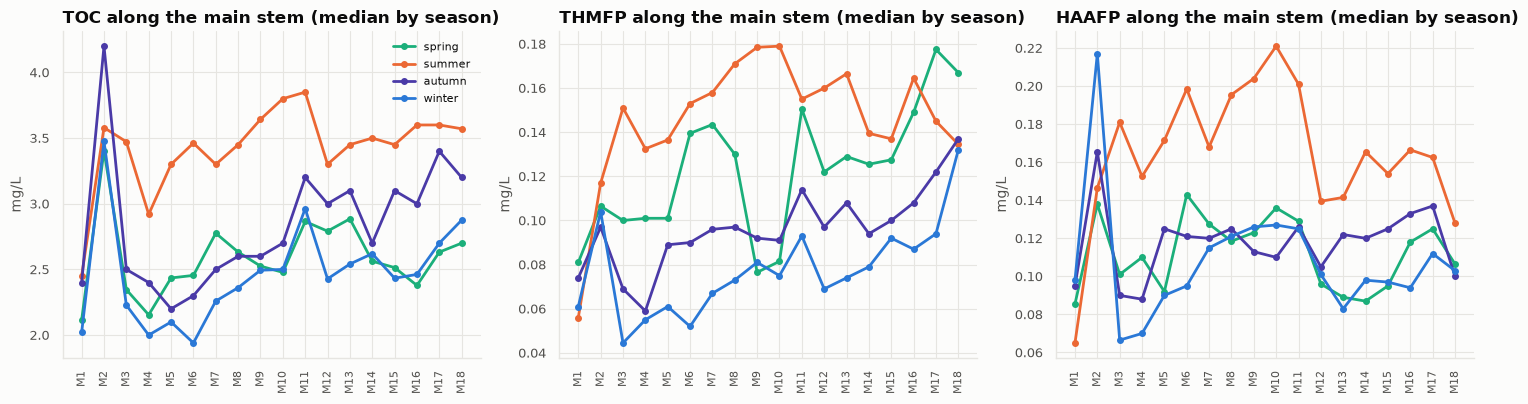

In [23]:
# Longitudinal profile along the main stem, by season
ms = df[df.group == "main_stem"].copy(); ms["Site"] = ms["Site"].cat.remove_unused_categories()
season_colors = dict(zip(["spring", "summer", "autumn", "winter"], ["#1baf7a", "#eb6834", "#4a3aa7", "#2a78d6"]))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, v in zip(axes, ["TOC", "THMFP", "HAAFP"]):
    for s_, c in season_colors.items():
        m = ms[ms.season == s_].groupby("Site", observed=True)[v].median()
        ax.plot(range(len(m)), m.values, color=c, marker="o", markersize=4, label=s_)
    ax.set_xticks(range(len(m))); ax.set_xticklabels(m.index, rotation=90, fontsize=8)
    ax.set_title(f"{v} along the main stem (median by season)"); ax.set_ylabel(UNITS[v])
axes[0].legend(fontsize=8)
fig.tight_layout(); style.savefig(fig, "18_site_profile"); plt.show()

In [24]:
# How much target variance do Site and Date explain on their own? (eta^2 from one-way ANOVA on log10 target)
def eta2(d, factor, t):
    s = d.dropna(subset=[t]); y = np.log10(s[t]); grand = y.mean()
    ss_b = sum(len(g) * (g.mean() - grand) ** 2 for _, g in y.groupby(s[factor], observed=True))
    return ss_b / ((y - grand) ** 2).sum()

pd.DataFrame({(lab, t): {f: eta2(d, f, t) for f in ["Site", "Date", "group", "season"]}
              for lab, d in [("all", df), ("river", river)] for t in TARGETS}).round(2)

all       river      
       THMFP HAAFP THMFP HAAFP
Site    0.33  0.59  0.24  0.37
Date    0.38  0.15  0.47  0.29
group   0.21  0.38  0.11  0.18
season  0.14  0.04  0.19  0.07

## 8. Complete-case audit for modeling

How many rows survive under candidate feature sets, per site group. Set A uses every predictor;
B drops the UV/size trio (absent for all treatment-train rows); C also drops the five variables that are
sparse for treatment-train rows (DO, SS, BOD, COD, NH3N).

In [25]:
feature_sets = {"A: all 18": PREDICTORS, "B: drop SUVA/Arom/MolW (15)": set_b, "C: core 10": set_c}
audit = pd.DataFrame({name: df.dropna(subset=cols + ["THMFP", "HAAFP"]).groupby("group", observed=True).size()
                          .reindex(GROUP_ORDER, fill_value=0)
                      for name, cols in feature_sets.items()})
audit.index = audit.index.astype(str)
audit.loc["total"] = audit.sum()
avail = df.groupby("group", observed=True).size(); avail.index = avail.index.astype(str)
audit["rows available"] = avail.reindex(audit.index).fillna(len(df)).astype(int)
audit

,A: all 18,B: drop SUVA/Arom/MolW (15),C: core 10,rows available
group,,,,
main_stem,211,283,283,288
tributary,66,91,91,96
reservoir,0,52,74,80
treatment,0,13,237,240
total,277,439,685,704


In [26]:
# Same audit as a share of available rows
(audit.drop(columns="rows available").div(audit["rows available"], axis=0) * 100).round(0).astype(int).astype(str) + " %"

,A: all 18,B: drop SUVA/Arom/MolW (15),C: core 10
group,,,
main_stem,73 %,98 %,98 %
tributary,69 %,95 %,95 %
reservoir,0 %,65 %,92 %
treatment,0 %,5 %,99 %
total,39 %,62 %,97 %


## 9. Findings

See `reports/eda_findings.md` for the written summary of this notebook (data quality, target behaviour,
strongest predictors, collinearity, recommended feature sets and open questions for the data owner).